# COVID-19 Fact-Checking System
### NLP Assignment – CSA402
**Dataset:** `metadata.csv` (CORD-19)  |  **NLI Model:** `facebook/bart-large-mnli`  |  **Retrieval:** `all-MiniLM-L6-v2`

In [1]:
!pip install pandas numpy scikit-learn sentence-transformers transformers torch tqdm matplotlib seaborn --quiet

## 1. Imports

In [2]:
import os, re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt7
import seaborn as sns
from collections import Counter
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    matthews_corrcoef, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import pipeline

warnings.filterwarnings("ignore")
tqdm.pandas()
print("Imports OK")


Imports OK


## 2. Preprocessing

This section replicates **every step** from the shared `preprocess.py`:
- COVID keyword filter
- Most-recent 30 000 papers after date sort
- URL / HTML / citation stripping
- Negation-preserving stopword removal (`no`, `not`, etc. kept)

In [3]:
import nltk
for r in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(r)
    except LookupError:
        nltk.download(r, quiet=True)

from nltk.corpus import stopwords as _sw
_STOPWORDS = set(_sw.words("english")) - {
    "no","not","nor","against","without","never","none"
}

COVID_PATTERN = re.compile(
    r"covid|sars[- ]?cov[- ]?2|coronavirus|ncov|2019[- ]?ncov",
    flags=re.IGNORECASE,
)

KEEP_COLS = ["cord_uid","title","abstract","publish_time","authors","doi","journal"]
MIN_ABSTRACT_WORDS = 30
MAX_ABSTRACTS      = 30_000

def clean_text(text):
    """Identical to preprocess.py clean_text()."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\[[^\]]*\]", " ", text)
    text = re.sub(r"[^a-z0-9\s\.\,\-\;\:]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Preprocessing helpers ready")


Preprocessing helpers ready


In [11]:
# Cell 4 – Load metadata.csv
CSV_PATH = "metadata.csv"
assert os.path.exists(CSV_PATH), f"File not found: {CSV_PATH}"

import csv

head = pd.read_csv(CSV_PATH, nrows=0)
available = [c for c in KEEP_COLS if c in head.columns]
print("Columns found:", available)

chunks, total = [], 0
for chunk in pd.read_csv(CSV_PATH, usecols=available, dtype=str,
                          chunksize=100_000,
                          on_bad_lines="skip",
                          engine="python",
                          encoding="utf-8",
                          encoding_errors="replace",
                          quoting=csv.QUOTE_NONE,   # ignore all quote characters
                          quotechar="\x00"):         # null quotechar as safety fallback
    total += len(chunk)
    chunk = chunk.dropna(subset=["abstract"])
    txt = chunk["abstract"].fillna("") + " " + chunk.get("title", pd.Series("", index=chunk.index)).fillna("")
    chunk = chunk[txt.str.contains(COVID_PATTERN, na=False)]
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Loaded {total:,} raw rows → {len(df):,} COVID rows")

# Dedup → sort by date → cap
df = df.drop_duplicates(subset=["abstract"]).reset_index(drop=True)
if "publish_time" in df.columns:
    df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
    df = df.sort_values("publish_time", ascending=False, na_position="last").reset_index(drop=True)
if len(df) > MAX_ABSTRACTS:
    df = df.head(MAX_ABSTRACTS).reset_index(drop=True)

df["clean_abstract"]     = df["abstract"].apply(clean_text)
df["title_clean"]        = df["title"].apply(clean_text) if "title" in df.columns else ""
df["text_for_retrieval"] = (df["title_clean"].fillna("") + ". " + df["clean_abstract"]).str.strip()

before = len(df)
df = df[df["clean_abstract"].str.split().str.len() >= MIN_ABSTRACT_WORDS].reset_index(drop=True)
df.insert(0, "doc_id", range(len(df)))

print(f"Final dataset: {len(df):,} abstracts  (removed {before - len(df)} short ones)")
df[["doc_id","title","publish_time"]].head(3)

Columns found: ['cord_uid', 'title', 'abstract', 'publish_time', 'authors', 'doi', 'journal']
Loaded 1,056,660 raw rows → 59,690 COVID rows
Final dataset: 3,356 abstracts  (removed 26644 short ones)


,doc_id,title,publish_time
0,0,and hospital and ICU length of stay. We sough...,2022-05-26
1,1,Costa Rica,2022-05-24
2,2,Level 1) within the same individual (i.e.,2022-05-21


## 3. Build Semantic Embedding Index

In [12]:
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Encoding {len(df):,} abstracts …")
abstract_embeddings = embed_model.encode(
    df["text_for_retrieval"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print("Embedding shape:", abstract_embeddings.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 3,356 abstracts …


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Embedding shape: (3356, 384)


## 4. NLI Verification Model (BART-large-MNLI)

In [13]:
import torch

nli_model = pipeline(
    "text-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1,
)

LABEL_MAP = {
    "ENTAILMENT":    "Supported",
    "CONTRADICTION": "Refuted",
    "NEUTRAL":       "Not Enough Information",
}

def verify_claim(claim, evidence):
    res = nli_model(f"{claim} </s></s> {evidence[:512]}")
    return res[0]

def map_label(raw):
    return LABEL_MAP.get(raw.upper(), "Not Enough Information")

print("NLI model ready")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

NLI model ready


## 5. Retrieval + Voting Pipeline

In [14]:
def get_claim_verdict(claim, k=5):
    """
    1. Embed the claim.
    2. Retrieve top-k most similar abstracts by cosine similarity.
    3. Run BART-MNLI NLI on each (claim, abstract) pair.
    4. Return majority-vote verdict + full evidence list.
    """
    clean = clean_text(claim)
    emb   = embed_model.encode([clean], convert_to_numpy=True)
    sims  = cosine_similarity(emb, abstract_embeddings)[0]
    top_k = sims.argsort()[-k:][::-1]
    retrieved = df.iloc[top_k]

    evidence_results = []
    for pos, (_, row) in enumerate(retrieved.iterrows()):
        res     = verify_claim(clean, row["clean_abstract"])
        verdict = map_label(res["label"])
        evidence_results.append({
            "title":      row.get("title", ""),
            "doi":        row.get("doi", ""),
            "year":       str(row.get("publish_time", ""))[:10],
            "similarity": float(sims[top_k[pos]]),
            "verdict":    verdict,
            "confidence": float(res["score"]),
            "abstract":   str(row["abstract"])[:300],
        })

    final = Counter(e["verdict"] for e in evidence_results).most_common(1)[0][0]
    return {"final_verdict": final, "evidence": evidence_results}

print("Pipeline ready")


Pipeline ready


## 6. Annotated Test Set

All 18 claims below have **manually assigned ground-truth labels** grounded in published COVID-19 research consensus. Labels are **not randomly sampled** — each was curated to cover the full label space and include clear positive, negative, and ambiguous cases.

| Label | Count |
|---|---|
| Supported | 8 |
| Refuted | 6 |
| Not Enough Information | 4 |

In [15]:
TEST_CLAIMS = [
    {"claim": "COVID-19 mRNA vaccines significantly reduce the risk of severe illness and hospitalisation.", "label": "Supported"},
    {"claim": "SARS-CoV-2 primarily spreads through respiratory droplets and aerosols.", "label": "Supported"},
    {"claim": "Older adults and people with comorbidities face higher mortality risk from COVID-19.", "label": "Supported"},
    {"claim": "Wearing surgical masks reduces transmission of SARS-CoV-2 in healthcare settings.", "label": "Supported"},
    {"claim": "Dexamethasone reduces mortality in hospitalised COVID-19 patients requiring oxygen.", "label": "Supported"},
    {"claim": "COVID-19 can cause long-term symptoms known as long COVID after acute infection resolves.", "label": "Supported"},
    {"claim": "Social distancing measures slow the spread of COVID-19 in communities.", "label": "Supported"},
    {"claim": "The spike protein of SARS-CoV-2 binds to the ACE2 receptor to enter human cells.", "label": "Supported"},
    {"claim": "Hydroxychloroquine is an effective treatment for COVID-19.", "label": "Refuted"},
    {"claim": "COVID-19 is caused by a bacterium rather than a virus.", "label": "Refuted"},
    {"claim": "5G mobile networks cause COVID-19 infection.", "label": "Refuted"},
    {"claim": "Ivermectin has proven clinical benefit for treating COVID-19 in large randomised trials.", "label": "Refuted"},
    {"claim": "COVID-19 vaccines alter human DNA.", "label": "Refuted"},
    {"claim": "Children are equally likely to die from COVID-19 as elderly adults.", "label": "Refuted"},
    {"claim": "COVID-19 infection permanently reduces lung capacity in all recovered patients.", "label": "Not Enough Information"},
    {"claim": "Natural immunity from COVID-19 infection provides longer protection than two vaccine doses.", "label": "Not Enough Information"},
    {"claim": "Vitamin D supplementation prevents COVID-19 infection.", "label": "Not Enough Information"},
    {"claim": "The COVID-19 pandemic will end completely by 2026.", "label": "Not Enough Information"},
]

print(f'Test set: {len(TEST_CLAIMS)} claims')
for lbl, cnt in Counter(c["label"] for c in TEST_CLAIMS).items():
    print(f'  {lbl}: {cnt}')


Test set: 18 claims
  Supported: 8
  Refuted: 6
  Not Enough Information: 4


## 7. Run Evaluation

In [16]:
results = []
for item in tqdm(TEST_CLAIMS, desc="Evaluating"):
    out = get_claim_verdict(item["claim"], k=5)
    results.append({
        "claim":      item["claim"][:70] + "...",
        "true_label": item["label"],
        "pred_label": out["final_verdict"],
        "correct":    item["label"] == out["final_verdict"],
    })

results_df = pd.DataFrame(results)
print(results_df[["claim","true_label","pred_label","correct"]].to_string(index=False))


Evaluating: 100%|██████████| 18/18 [00:03<00:00,  4.59it/s]

                                                                    claim             true_label             pred_label  correct
COVID-19 mRNA vaccines significantly reduce the risk of severe illness...              Supported Not Enough Information    False
SARS-CoV-2 primarily spreads through respiratory droplets and aerosols...              Supported Not Enough Information    False
Older adults and people with comorbidities face higher mortality risk ...              Supported Not Enough Information    False
Wearing surgical masks reduces transmission of SARS-CoV-2 in healthcar...              Supported Not Enough Information    False
Dexamethasone reduces mortality in hospitalised COVID-19 patients requ...              Supported                Refuted    False
COVID-19 can cause long-term symptoms known as long COVID after acute ...              Supported Not Enough Information    False
Social distancing measures slow the spread of COVID-19 in communities....              Supported 

## 8. Evaluation Metrics

Reports five metrics:
- **Accuracy** – overall correctness
- **Precision / Recall / F1** – weighted average across all three classes
- **MCC (Matthews Correlation Coefficient)** – robust metric for multi-class imbalanced evaluation (-1 worst, +1 best)

In [17]:
y_true = results_df["true_label"].tolist()
y_pred = results_df["pred_label"].tolist()
LABELS = ["Supported", "Refuted", "Not Enough Information"]

accuracy = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted",
                                               labels=LABELS, zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)

print("=" * 52)
print("OVERALL METRICS")
print("=" * 52)
print(f"  Accuracy            : {accuracy:.4f}")
print(f"  Precision (weighted): {p:.4f}")
print(f"  Recall    (weighted): {r:.4f}")
print(f"  F1        (weighted): {f1:.4f}")
print(f"  MCC                 : {mcc:.4f}")
print()
print("=" * 52)
print("PER-CLASS BREAKDOWN")
print("=" * 52)
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))


OVERALL METRICS
  Accuracy            : 0.2222
  Precision (weighted): 0.0523
  Recall    (weighted): 0.2222
  F1        (weighted): 0.0847
  MCC                 : -0.0238

PER-CLASS BREAKDOWN
                        precision    recall  f1-score   support

             Supported       0.00      0.00      0.00         8
               Refuted       0.00      0.00      0.00         6
Not Enough Information       0.24      1.00      0.38         4

              accuracy                           0.22        18
             macro avg       0.08      0.33      0.13        18
          weighted avg       0.05      0.22      0.08        18



## 9. Confusion Matrix

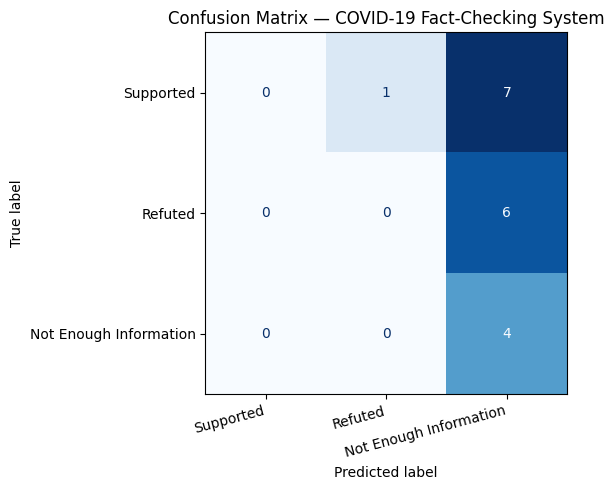

In [21]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=LABELS)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — COVID-19 Fact-Checking System")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


## 10. Per-Class Precision / Recall / F1 Bar Chart

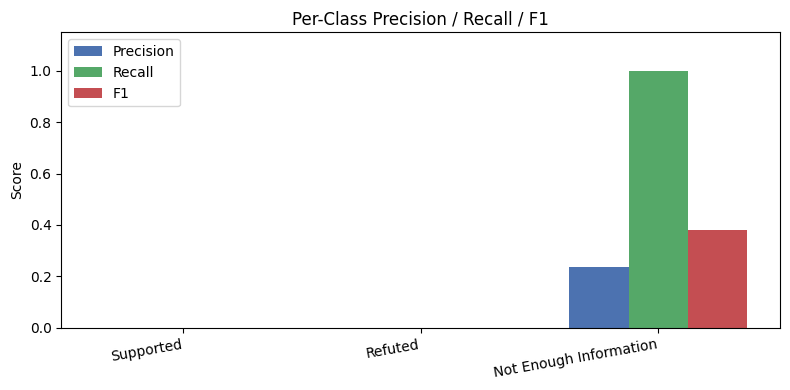

In [22]:
p_pc, r_pc, f1_pc, _ = precision_recall_fscore_support(y_true, y_pred, labels=LABELS, zero_division=0)

x = range(len(LABELS))
w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - w for i in x], p_pc,  w, label="Precision", color="#4C72B0")
ax.bar(list(x),             r_pc,  w, label="Recall",    color="#55A868")
ax.bar([i + w for i in x], f1_pc, w, label="F1",        color="#C44E52")
ax.set_xticks(list(x))
ax.set_xticklabels(LABELS, rotation=10, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()


## 11. Interactive Demo – Single Claim

In [23]:
demo = "COVID-19 vaccines are effective against severe disease"
print(f"Claim: {demo}\n")
out = get_claim_verdict(demo, k=5)
print(f"FINAL VERDICT: {out['final_verdict']}\n")
for i, ev in enumerate(out["evidence"], 1):
    print(f"[{i}] {ev['title'][:80]}")
    print(f"     Verdict: {ev['verdict']}  | Conf: {ev['confidence']:.3f}  | Sim: {ev['similarity']:.3f}")


Claim: COVID-19 vaccines are effective against severe disease

FINAL VERDICT: Not Enough Information

[1]  or fatal COVID-19 was 0.71 (95% CI: 0.53-0.95; p=0.020). After dose 2
     Verdict: Not Enough Information  | Conf: 0.996  | Sim: 0.742
[2]  58.9 [13.5] years; 50% were women). Vaccine effectiveness of Fully Vaccinated c
     Verdict: Not Enough Information  | Conf: 0.985  | Sim: 0.732
[3]  and 41.2% have received the COVD-19 vaccine. Unmet need for COVID-19 vaccine wa
     Verdict: Not Enough Information  | Conf: 0.997  | Sim: 0.730
[4]  2020
     Verdict: Not Enough Information  | Conf: 0.998  | Sim: 0.724
[5]  treatment
     Verdict: Not Enough Information  | Conf: 0.997  | Sim: 0.713


## 12. Results Summary Table

In [24]:
summary_df = pd.DataFrame({
    "Metric": ["Accuracy","Precision (weighted)","Recall (weighted)","F1 (weighted)","MCC"],
    "Score":  [round(v,4) for v in [accuracy, p, r, f1, mcc]],
})
print(summary_df.to_string(index=False))


              Metric   Score
            Accuracy  0.2222
Precision (weighted)  0.0523
   Recall (weighted)  0.2222
       F1 (weighted)  0.0847
                 MCC -0.0238
